# 🔍 Ethereum Fraud Detection

**Goal:** Build a machine-learning classifier that identifies fraudulent Ethereum wallet addresses.

**Dataset:** `transaction_dataset.csv` — on-chain features for Ethereum addresses, labelled `0` (legit) or `1` (fraud).

**Workflow:**
1. Load & explore the data  
2. Clean & pre-process  
3. Exploratory Data Analysis (EDA)  
4. Feature engineering  
5. Train & evaluate models (Random Forest + XGBoost)  
6. Interpret results  


## 1. Imports

We use standard data-science libraries plus two powerful tree-based classifiers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score
)
from xgboost import XGBClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Nicer plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. Load & First Look at the Data

We load the CSV and immediately drop the first two columns (an unnamed index and a redundant one) plus the wallet `Address` column — none of them carry predictive signal.


In [2]:
df = pd.read_csv('transaction_dataset.csv')

# Drop the first two unnamed/index columns, then drop 'Address'
df = df.iloc[:, 2:]
df.drop(columns=['Address'], inplace=True)

print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (9841, 48)


,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,844.26,1093.71,704785.63,721,89,0,40,118,0.000000,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,0,12709.07,2958.44,1218216.73,94,8,0,5,14,0.000000,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,0,246194.54,2434.02,516729.30,2,10,0,10,2,0.113119,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,0,10219.60,15785.09,397555.90,25,9,0,7,13,0.000000,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,0,36.61,10707.77,382472.42,4598,20,1,7,19,0.000000,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841 entries, 0 to 9840
Data columns (total 48 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   FLAG                                                  9841 non-null   int64  
 1   Avg min between sent tnx                              9841 non-null   float64
 2   Avg min between received tnx                          9841 non-null   float64
 3   Time Diff between first and last (Mins)               9841 non-null   float64
 4   Sent tnx                                              9841 non-null   int64  
 5   Received Tnx                                          9841 non-null   int64  
 6   Number of Created Contracts                           9841 non-null   int64  
 7   Unique Received From Addresses                        9841 non-null   int64  
 8   Unique Sent To Addresses                              9841

In [4]:
df.describe(include=['int64', 'float64'])


,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,Unique Received From Addresses,Unique Sent To Addresses,min value received,...,ERC20 max val rec,ERC20 avg val rec,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name
count,9841.000000,9841.000000,9841.000000,9.841000e+03,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,9841.000000,...,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9.012000e+03,9012.0,9012.0,9012.0,9012.000000,9012.000000
mean,0.221421,5086.878721,8004.851184,2.183333e+05,115.931714,163.700945,3.729702,30.360939,25.840159,43.845153,...,1.252524e+08,4.346203e+06,1.174126e+04,1.303594e+07,6.318389e+06,0.0,0.0,0.0,1.384931,4.826676
std,0.415224,21486.549974,23081.714801,3.229379e+05,757.226361,940.836550,141.445583,298.621112,263.820410,325.929139,...,1.053741e+10,2.141192e+08,1.053567e+06,1.179905e+09,5.914764e+08,0.0,0.0,0.0,6.735121,16.678607
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
25%,0.000000,0.000000,0.000000,3.169300e+02,1.000000,1.000000,0.000000,1.000000,1.000000,0.001000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,0.000000
50%,0.000000,17.340000,509.770000,4.663703e+04,3.000000,4.000000,0.000000,2.000000,2.000000,0.095856,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,1.000000
75%,0.000000,565.470000,5480.390000,3.040710e+05,11.000000,27.000000,0.000000,5.000000,3.000000,2.000000,...,9.900000e+01,2.946467e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.000000,2.000000
max,1.000000,430287.670000,482175.490000,1.954861e+06,10000.000000,10000.000000,9995.000000,9999.000000,9287.000000,10000.000000,...,1.000000e+12,1.724181e+10,1.000000e+08,1.120000e+11,5.614756e+10,0.0,0.0,0.0,213.000000,737.000000


## 3. Target Variable — Class Distribution

`FLAG = 1` means the address is a known fraud.  
Checking class balance is crucial: a heavily imbalanced dataset can make a model *look* accurate while just predicting the majority class every time.


In [5]:
print(df['FLAG'].value_counts())
print(f"\nFraud rate: {df['FLAG'].mean()*100:.1f}%")


FLAG
0    7662
1    2179
Name: count, dtype: int64

Fraud rate: 22.1%


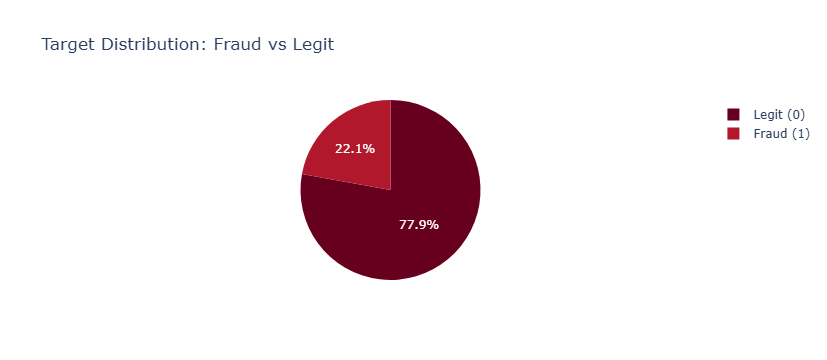

In [6]:
fig = px.pie(
    values=df['FLAG'].value_counts().values,
    names=['Legit (0)', 'Fraud (1)'],
    title='Target Distribution: Fraud vs Legit',
    color_discrete_sequence=px.colors.sequential.RdBu
)
fig.show()


## 4. Data Cleaning

### 4a. Remove Non-Numeric Columns
Text/object columns can't be fed directly into sklearn models without encoding.  
We inspect them first, then drop them (they are mostly token names/identifiers with very high cardinality and low value).


In [7]:
cat_cols = df.select_dtypes('object').columns
print(f'Categorical columns ({len(cat_cols)}): {cat_cols.tolist()}')

# High cardinality check
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')


Categorical columns (2): [' ERC20 most sent token type', ' ERC20_most_rec_token_type']
   ERC20 most sent token type: 304 unique values
   ERC20_most_rec_token_type: 466 unique values


In [8]:
df.drop(columns=cat_cols, inplace=True)
print(f'Shape after dropping categorical columns: {df.shape}')


Shape after dropping categorical columns: (9841, 46)


### 4b. Remove Zero-Variance Features

A feature with zero variance has the same value for every row — it carries no information and should be removed.


In [10]:
zero_var_cols = df.columns[df.var() == 0]
print(f'Zero-variance columns ({len(zero_var_cols)}): {zero_var_cols.tolist()}')

df.drop(columns=zero_var_cols, inplace=True)
print(f'Shape after removing zero-variance columns: {df.shape}')


Zero-variance columns (0): []
Shape after removing zero-variance columns: (9841, 39)


### 4c. Missing Values

Before modelling we check for missing values. We will impute them with the **median** (more robust than mean for skewed financial data).


In [11]:
missing = df.isnull().sum()
print('Columns with missing values:')
print(missing[missing > 0])
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')


Columns with missing values:
Total ERC20 tnxs                   829
ERC20 total Ether received         829
ERC20 total ether sent             829
ERC20 total Ether sent contract    829
ERC20 uniq sent addr               829
ERC20 uniq rec addr                829
ERC20 uniq sent addr.1             829
ERC20 uniq rec contract addr       829
ERC20 min val rec                  829
ERC20 max val rec                  829
ERC20 avg val rec                  829
ERC20 min val sent                 829
ERC20 max val sent                 829
ERC20 avg val sent                 829
ERC20 uniq sent token name         829
ERC20 uniq rec token name          829
dtype: int64

Total missing cells: 13264


## 5. Exploratory Data Analysis (EDA)

### 5a. Correlation Heatmap (Full)

A heatmap shows pairwise correlations. High correlation between two features means they carry redundant information — we can remove one without losing predictive power.


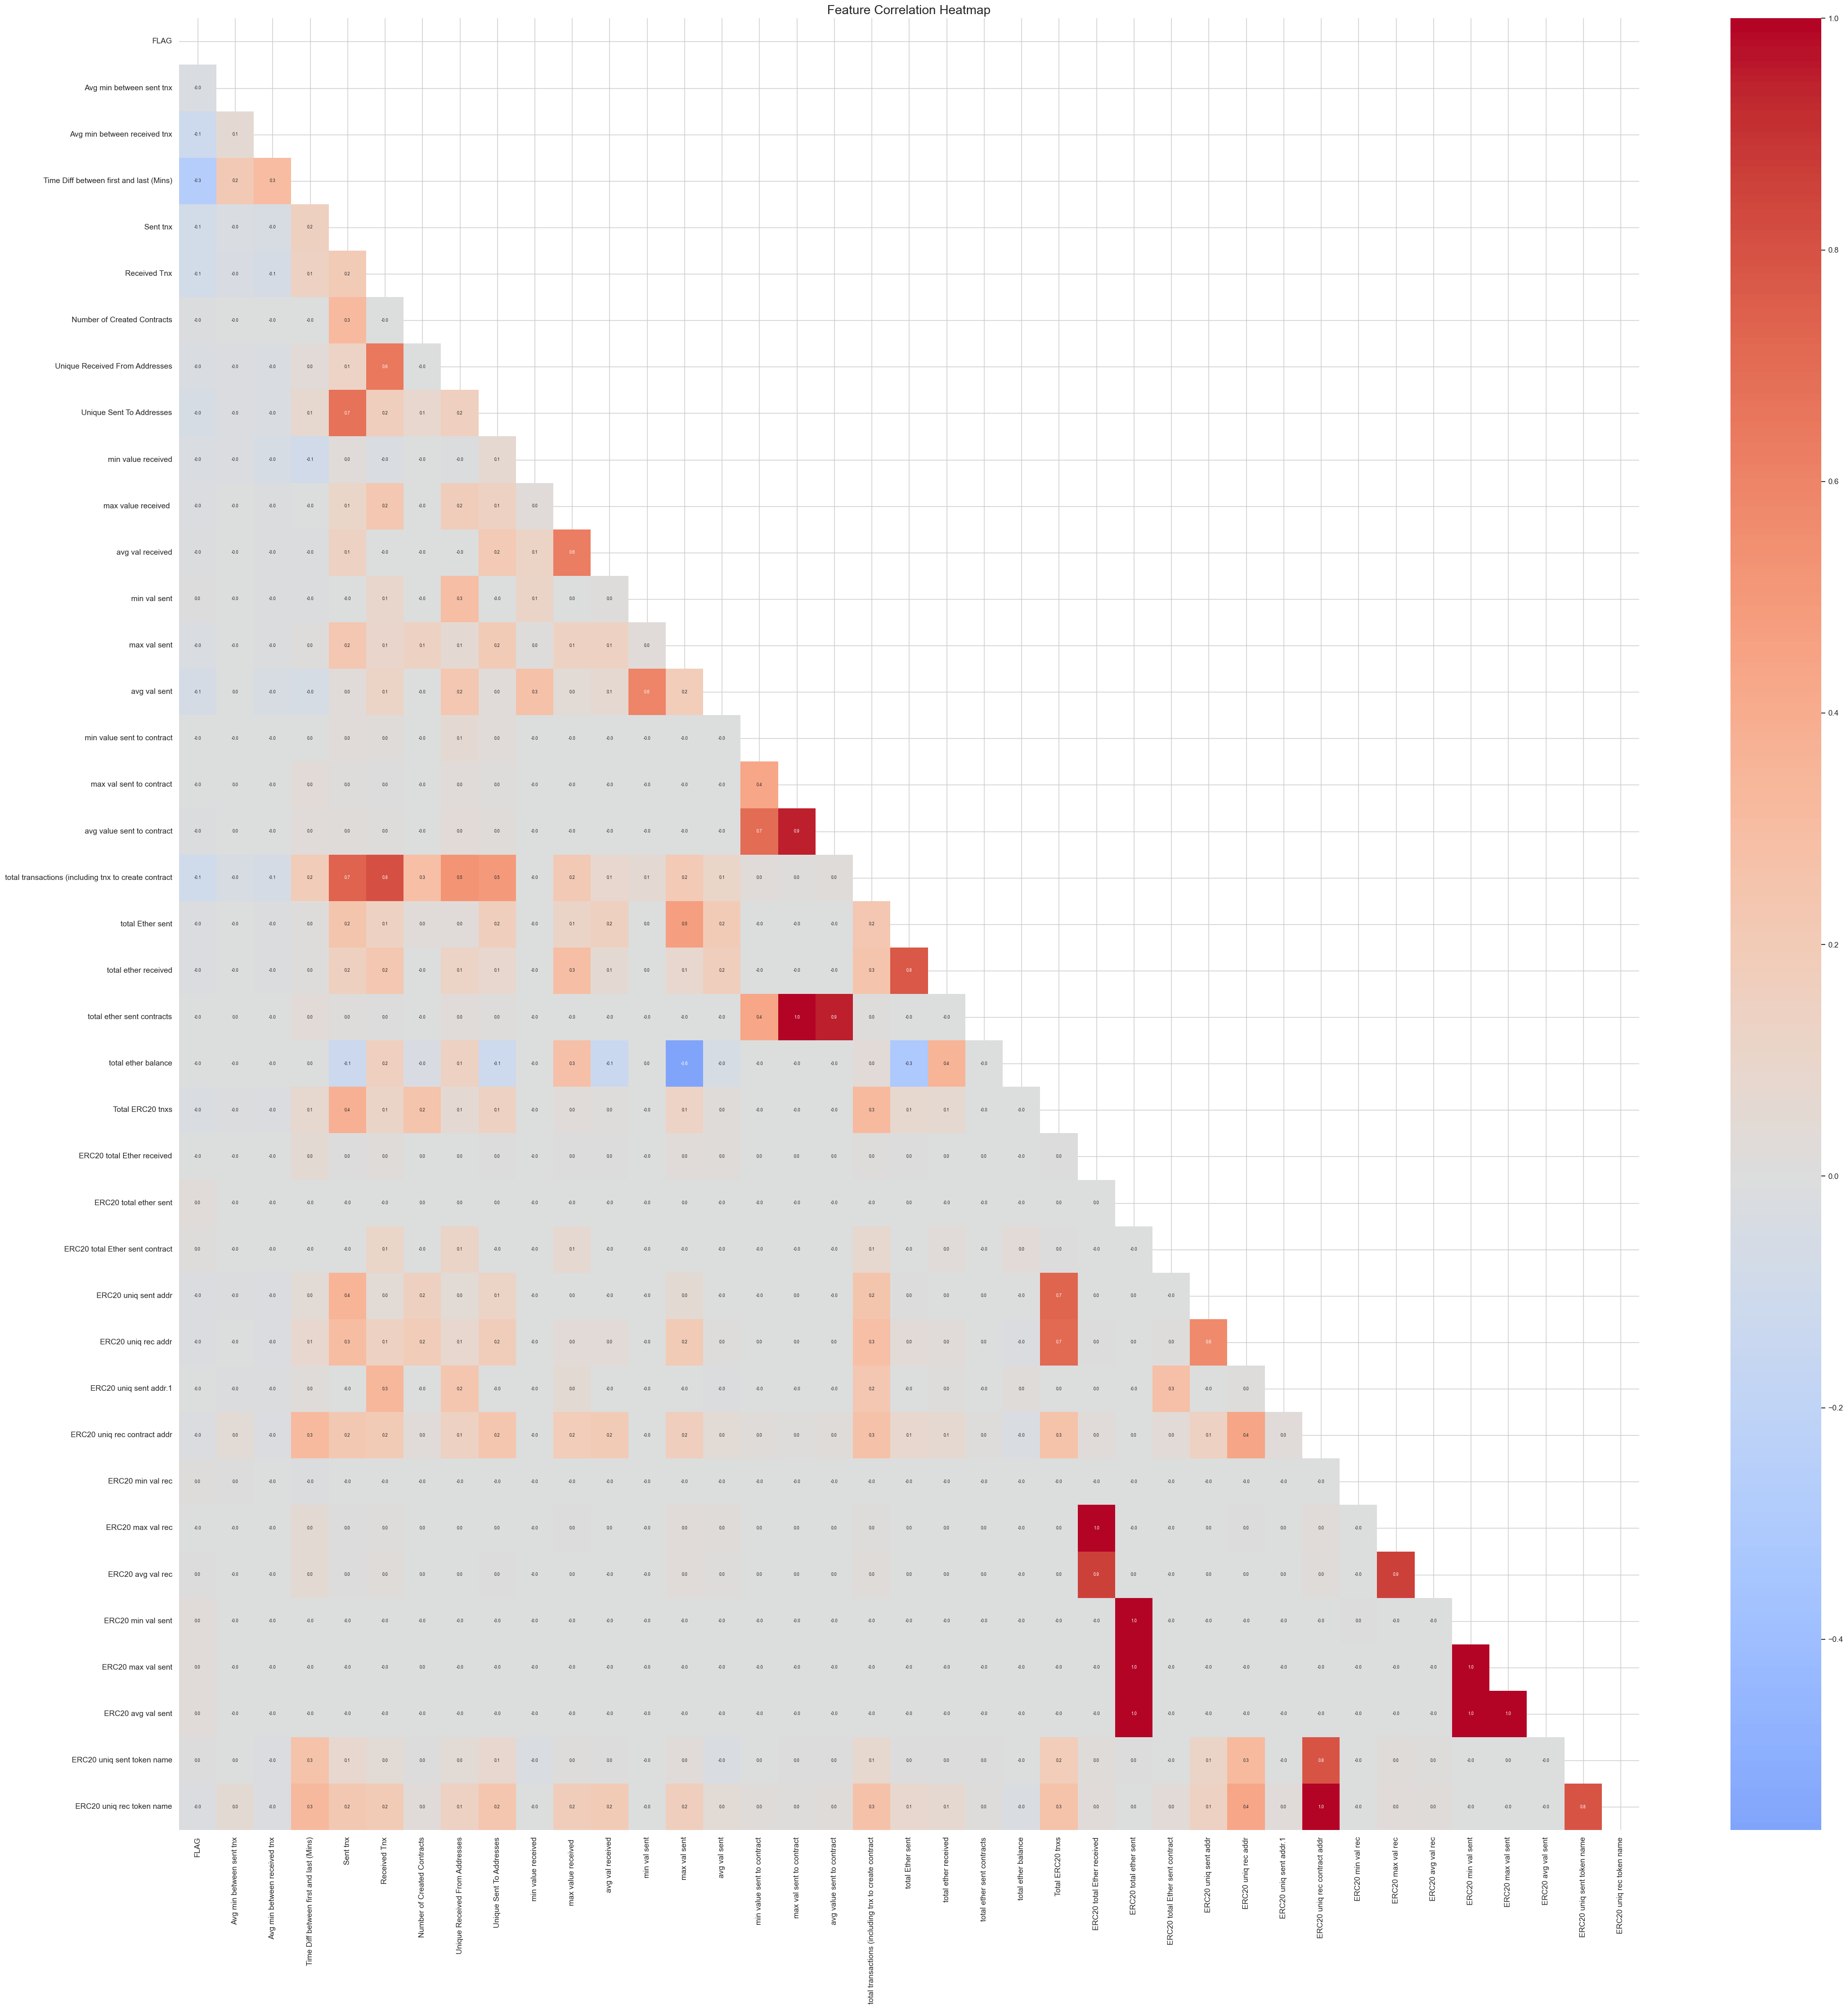

In [12]:
corr = df.corr(numeric_only=True)

# Only show the lower triangle (the upper is a mirror image)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(40, 40))
sns.heatmap(corr, annot=True, fmt='.1f', mask=mask,
            cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 6})
ax.set_title('Feature Correlation Heatmap', fontsize=18)
plt.tight_layout()
plt.show()


### 5b. Feature Correlations with the Target (`FLAG`)

Sorting features by their absolute correlation with `FLAG` helps us understand which features are most relevant.


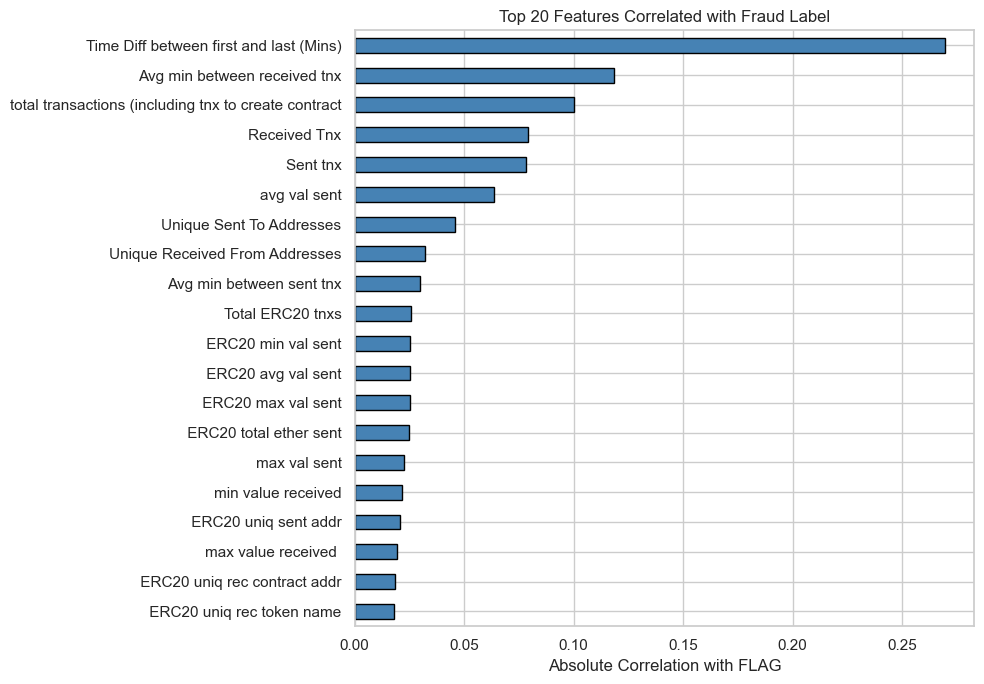

In [13]:
target_corr = corr['FLAG'].drop('FLAG').abs().sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(10, 7))
target_corr.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Absolute Correlation with FLAG')
plt.title('Top 20 Features Correlated with Fraud Label')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Feature Selection — Drop Highly Correlated Features

The columns below are either highly correlated with another feature (multicollinearity) or have very low correlation with the target.  
Removing them reduces noise and speeds up training.


In [ ]:
cols_to_drop = [
    'total transactions (including tnx to create contract',
    'total ether sent contracts',
    'max val sent to contract',
    ' ERC20 avg val rec',
    ' ERC20 max val rec',
    ' ERC20 min val rec',
    ' ERC20 uniq rec contract addr',
    'max val sent',
    ' ERC20 avg val sent',
    ' ERC20 min val sent',
    ' ERC20 max val sent',
    ' Total ERC20 tnxs',
    'avg value sent to contract',
    'Unique Sent To Addresses',
    'Unique Received From Addresses',
    'total ether received',
    ' ERC20 uniq sent token name',
    'min value received',
    'min val sent',
    ' ERC20 uniq rec addr',
]

# Only drop columns that still exist (guard against re-runs)
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

print(f'Shape after feature selection: {df.shape}')
print(f'Remaining columns: {df.columns.tolist()}')


### Reduced Correlation Heatmap

After removing redundant features, the heatmap becomes much more readable.


In [ ]:
corr_reduced = df.corr(numeric_only=True)
mask_reduced = np.triu(np.ones_like(corr_reduced, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(corr_reduced, annot=True, fmt='.2f', mask=mask_reduced,
            cmap='coolwarm', center=0, ax=ax)
ax.set_title('Reduced Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


## 7. Train / Test Split

We separate the data into **features** (X) and **target** (y), then split 75 % / 25 %.  
Using `stratify=y` ensures both splits have the same fraud ratio — important for imbalanced data.


In [ ]:
X = df.drop(columns=['FLAG'])
y = df['FLAG']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y          # keeps class balance in both splits
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')


## 8. Pre-processing

> ⚠️ **Fit only on training data, then transform both sets.**  
> Fitting on the full dataset causes *data leakage* — the model indirectly "sees" test data during training, leading to over-optimistic scores.

**Step 1 — Impute missing values** with the column median.  
**Step 2 — Scale** features to zero mean / unit variance (StandardScaler).  
Tree-based models (RF, XGBoost) don't need scaling, but it does no harm and keeps the pipeline general.


In [ ]:
# --- Imputation ---
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# --- Scaling ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Pre-processing complete.')
print(f'X_train shape: {X_train.shape} | X_test shape: {X_test.shape}')


## 9. Hyperparameter Tuning — Random Forest (GridSearchCV)

We search a small grid of hyperparameters for the Random Forest model using 3-fold cross-validation.  
`StratifiedKFold` preserves the fraud ratio in each fold.  

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of trees |
| `max_depth` | Maximum depth of each tree |
| `min_samples_split` | Minimum samples required to split a node |

> **Note:** GridSearchCV can take several minutes depending on your hardware.


In [ ]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, None],
    'min_samples_split': [2, 5, 10],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',          # optimise for F1 (better for imbalanced data than accuracy)
    n_jobs=-1,             # use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV F1 score: {grid_search.best_score_:.4f}')


## 10. Model Training & Evaluation

We train two models:
- **Random Forest** — with the best hyperparameters found above  
- **XGBoost** — with default settings as a strong baseline  

We report four metrics for each:

| Metric | Why it matters here |
|---|---|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of predicted frauds, how many were real? (avoid false alarms) |
| **Recall** | Of real frauds, how many did we catch? (avoid missed fraud) |
| **F1 Score** | Harmonic mean of Precision & Recall — best single metric for imbalanced data |
| **ROC-AUC** | Model's ability to separate classes across all thresholds |


In [ ]:
best_rf_params = grid_search.best_params_

models = {
    'Random Forest': RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE),
    'XGBoost':       XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    }

results_df = pd.DataFrame(results).T
print(results_df.round(4).to_string())


## 11. Confusion Matrices

The confusion matrix shows:
- **True Negatives (TN):** Legit addresses correctly classified  
- **False Positives (FP):** Legit addresses wrongly flagged as fraud  
- **False Negatives (FN):** Fraud addresses missed by the model  
- **True Positives (TP):** Fraud addresses correctly caught  

In fraud detection, **False Negatives are costly** — missed frauds can cause real financial harm.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud']
    )
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 12. Detailed Classification Report

The full classification report breaks down Precision, Recall, and F1 per class.


In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))


## 13. Feature Importance (Random Forest)

Tree-based models give us a free feature importance ranking — which features drove the predictions most.  
This is valuable for business understanding and for further feature engineering.


In [ ]:
feature_names = df.drop(columns=['FLAG']).columns

best_rf = models['Random Forest']
importances = pd.Series(best_rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='darkorange', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 14. Conclusion & Next Steps

### What we built
A fraud detection pipeline for Ethereum transactions that:
- Cleans and explores raw blockchain data
- Selects informative features using correlation analysis
- Tunes a Random Forest classifier with GridSearchCV
- Compares Random Forest and XGBoost on multiple metrics

### Key takeaways
- Always check class balance — accuracy alone can be misleading on imbalanced data
- Feature selection (removing zero-variance and highly correlated columns) is as important as model choice
- F1 Score and ROC-AUC are more meaningful metrics than accuracy for fraud detection

### Ideas for further improvement
| Idea | Expected benefit |
|---|---|
| SMOTE / class weights | Better handling of class imbalance |
| SHAP values | Deeper model explainability |
| Threshold tuning | Trade off precision vs recall for business needs |
| LightGBM / CatBoost | Potentially higher performance |
| Cross-validated evaluation | More reliable performance estimates |
